In [32]:
import pandas as pd
import numpy as np
import os

BASE_DIR = os.getcwd()
RAW_DATA_DIR = os.path.join(BASE_DIR, "data")
CLEAN_DATA_DIR = os.path.join(BASE_DIR, "data", "cleaned")

os.makedirs(CLEAN_DATA_DIR, exist_ok=True)

DATA_PATH = os.path.join(RAW_DATA_DIR, "Crime_Data_from_2020_to_Present.csv")
CLEAN_PATH = os.path.join(CLEAN_DATA_DIR, "Crime_Data_from_2020_to_Present_Cleaned_Draft2.csv")
QUALITY_PATH = os.path.join(CLEAN_DATA_DIR, "quality_report_Draft2.csv")

df = pd.read_csv(DATA_PATH)

df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1004991 non-null  int64  
 1   Date Rptd       1004991 non-null  object 
 2   DATE OCC        1004991 non-null  object 
 3   TIME OCC        1004991 non-null  int64  
 4   AREA            1004991 non-null  int64  
 5   AREA NAME       1004991 non-null  object 
 6   Rpt Dist No     1004991 non-null  int64  
 7   Part 1-2        1004991 non-null  int64  
 8   Crm Cd          1004991 non-null  int64  
 9   Crm Cd Desc     1004991 non-null  object 
 10  Mocodes         853372 non-null   object 
 11  Vict Age        1004991 non-null  int64  
 12  Vict Sex        860347 non-null   object 
 13  Vict Descent    860335 non-null   object 
 14  Premis Cd       1004975 non-null  float64
 15  Premis Desc     1004403 non-null  object 
 16  Weapon Used Cd  327247 non-null   fl

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004991e+06,1.004975e+06,327247.000000,1.004980e+06,69160.000000,2314.000000,64.00000,1.004991e+06,1.004991e+06
mean,2.202215e+08,1.339900e+03,1.069174e+01,1.115633e+03,1.400348e+00,5.001568e+02,2.891706e+01,3.056201e+02,363.955300,4.999174e+02,958.101258,984.015990,991.21875,3.399821e+01,-1.180909e+02
std,1.319718e+07,6.510613e+02,6.110255e+00,6.111605e+02,4.899691e-01,2.052731e+02,2.199272e+01,2.193021e+02,123.734528,2.050736e+02,110.354348,52.350982,27.06985,1.610713e+00,5.582386e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209159e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311103e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [33]:
df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")
df["TIME OCC"] = pd.to_numeric(df["TIME OCC"], errors="coerce")

df["occ_hour_raw"] = (df["TIME OCC"] // 100)
df["occ_minute_raw"] = (df["TIME OCC"] % 100)
df["occ_hour"] = df["occ_hour_raw"].where(df["occ_hour_raw"].between(0, 23), np.nan)
df["occ_minute"] = df["occ_minute_raw"].where(df["occ_minute_raw"].between(0, 59), np.nan)
df["occ_hour_filled"] = df["occ_hour"].fillna(0).astype(int)
df["occ_datetime"] = df["date_occ"] + pd.to_timedelta(df["occ_hour_filled"], unit="h")

df = df.dropna(subset=["date_occ", "LAT", "LON"])
df = df[(df["LAT"] != 0) & (df["LON"] != 0)]
df = df[df["LAT"].between(-90, 90) & df["LON"].between(-180, 180)]

C:\Users\aryam\AppData\Local\Temp\ipykernel_9660\575269729.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_occ"] = pd.to_datetime(df["DATE OCC"], errors="coerce")


In [34]:
df["year"] = df["occ_datetime"].dt.year
df["month"] = df["occ_datetime"].dt.month
df["day_of_week"] = df["occ_datetime"].dt.day_name()
df["weekday_num"] = df["occ_datetime"].dt.weekday
df["is_weekend"] = df["weekday_num"].isin([5, 6]).astype(int)

def time_bucket(hour):
    if pd.isna(hour): return "Unknown"
    hour = int(hour)
    if 0 <= hour <= 5: return "Night"
    elif 6 <= hour <= 11: return "Morning"
    elif 12 <= hour <= 17: return "Afternoon"
    elif 18 <= hour <= 23: return "Evening"
    return "Unknown"

df["time_bucket"] = df["occ_hour_filled"].apply(time_bucket)

if "Part 1-2" in df.columns:
    df["crime_category"] = df["Part 1-2"].map({1: "Part1", 2: "Part2"}).fillna("Unknown")
    df["crime_category_simple"] = df["Part 1-2"].map({
        1: "Violent/Serious (Part 1)",
        2: "Property/Other (Part 2)"
    }).fillna("Unknown")

df.to_csv(CLEAN_PATH, index=False)

In [35]:
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1002751 entries, 0 to 1004990
Data columns (total 43 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   DR_NO                  1002751 non-null  int64         
 1   Date Rptd              1002751 non-null  object        
 2   DATE OCC               1002751 non-null  object        
 3   TIME OCC               1002751 non-null  int64         
 4   AREA                   1002751 non-null  int64         
 5   AREA NAME              1002751 non-null  object        
 6   Rpt Dist No            1002751 non-null  int64         
 7   Part 1-2               1002751 non-null  int64         
 8   Crm Cd                 1002751 non-null  int64         
 9   Crm Cd Desc            1002751 non-null  object        
 10  Mocodes                851256 non-null   object        
 11  Vict Age               1002751 non-null  int64         
 12  Vict Sex               858185 non

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,...,occ_hour_raw,occ_minute_raw,occ_hour,occ_minute,occ_hour_filled,occ_datetime,year,month,weekday_num,is_weekend
count,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002735e+06,326414.000000,1.002740e+06,...,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06,1002751,1.002751e+06,1.002751e+06,1.002751e+06,1.002751e+06
mean,2.202494e+08,1.339982e+03,1.069231e+01,1.115687e+03,1.399672e+00,4.997775e+02,2.891327e+01,3.055341e+02,363.875682,4.995379e+02,...,1.322171e+01,1.781063e+01,1.322171e+01,1.781063e+01,1.322171e+01,2022-05-15 06:43:15.526507264,2.021882e+03,6.370519e+00,3.023610e+00,2.856442e-01
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2020-01-01 00:00:00,2.020000e+03,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.106179e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,...,9.000000e+00,0.000000e+00,9.000000e+00,0.000000e+00,9.000000e+00,2021-04-07 15:00:00,2.021000e+03,3.000000e+00,1.000000e+00,0.000000e+00
50%,2.209175e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,...,1.400000e+01,1.500000e+01,1.400000e+01,1.500000e+01,1.400000e+01,2022-05-28 00:00:00,2.022000e+03,6.000000e+00,3.000000e+00,0.000000e+00
75%,2.311111e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,...,1.900000e+01,3.000000e+01,1.900000e+01,3.000000e+01,1.900000e+01,2023-06-23 03:00:00,2.023000e+03,9.000000e+00,5.000000e+00,1.000000e+00
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,...,2.300000e+01,5.900000e+01,2.300000e+01,5.900000e+01,2.300000e+01,2025-05-29 08:00:00,2.025000e+03,1.200000e+01,6.000000e+00,1.000000e+00
std,1.319675e+07,6.513743e+02,6.110136e+00,6.111473e+02,4.898310e-01,2.051349e+02,2.199290e+01,2.193040e+02,123.820674,2.049347e+02,...,6.513336e+00,1.814364e+01,6.513336e+00,1.814364e+01,6.513336e+00,NaN,1.315033e+00,3.464177e+00,1.987271e+00,4.517209e-01


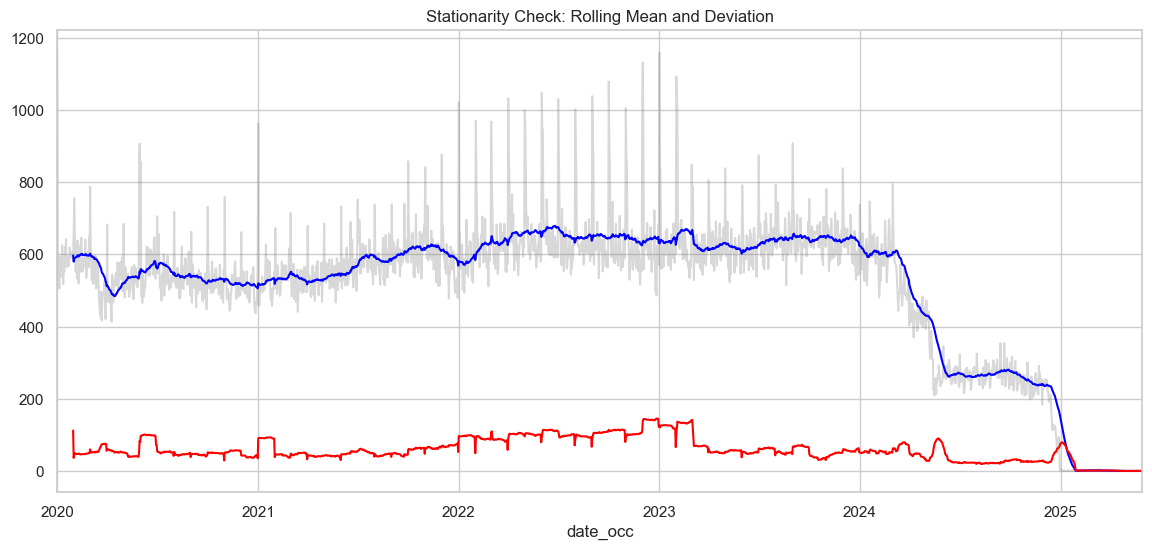

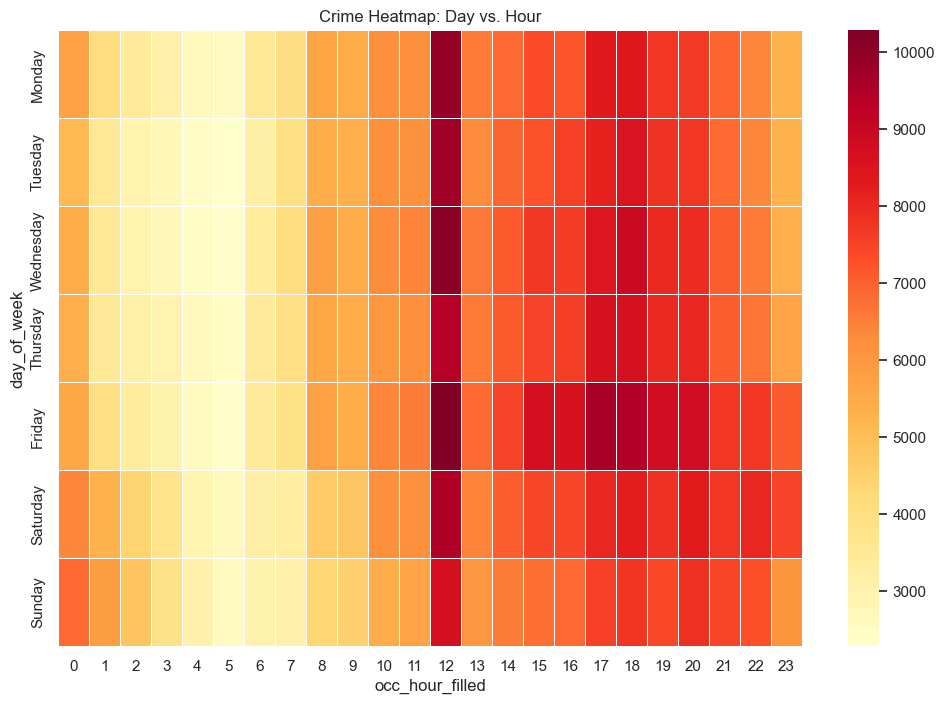

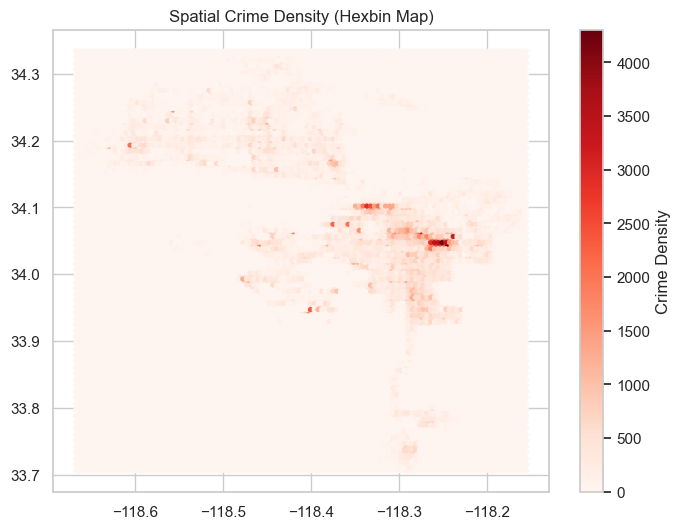

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
daily_counts = df.set_index('date_occ').resample('D').size()

plt.figure(figsize=(14, 6))
daily_counts.plot(alpha=0.3, color='gray')
daily_counts.rolling(window=30).mean().plot(color='blue')
daily_counts.rolling(window=30).std().plot(color='red')
plt.title('Stationarity Check: Rolling Mean and Deviation')
plt.show()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_table = df.pivot_table(index="day_of_week", columns="occ_hour_filled", values="DR_NO", aggfunc="count").reindex(days_order)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=.5)
plt.title("Crime Heatmap: Day vs. Hour")
plt.show()

plt.figure(figsize=(8,6))
plt.hexbin(df["LON"], df["LAT"], gridsize=120, cmap="Reds")
plt.colorbar(label="Crime Density")
plt.title("Spatial Crime Density (Hexbin Map)")
plt.show()

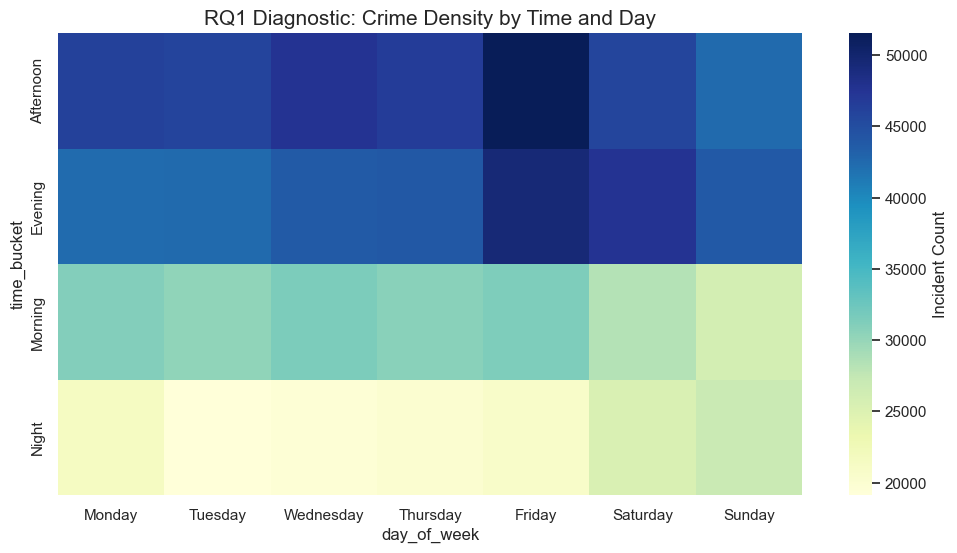

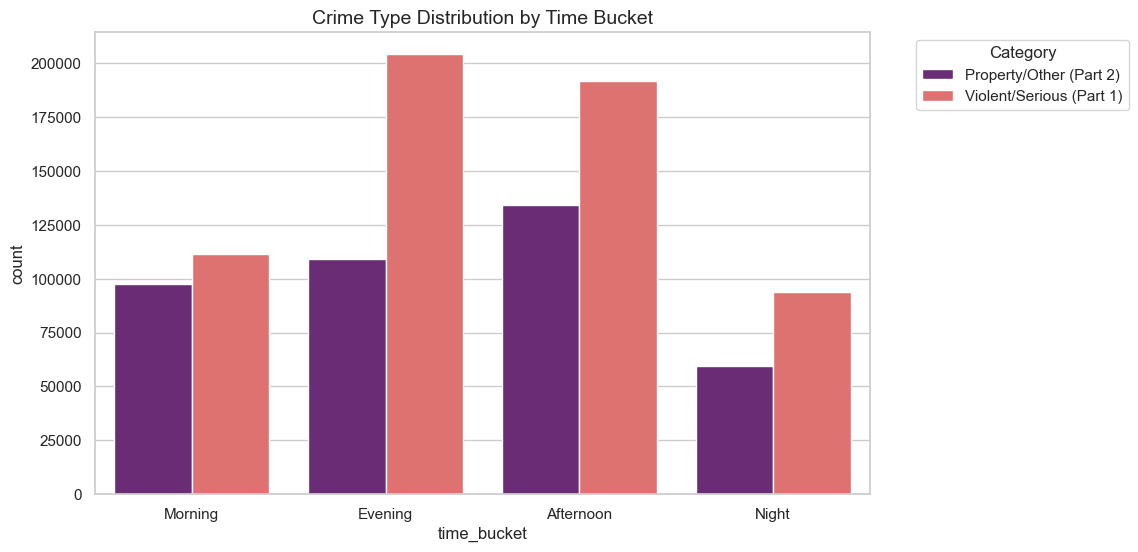

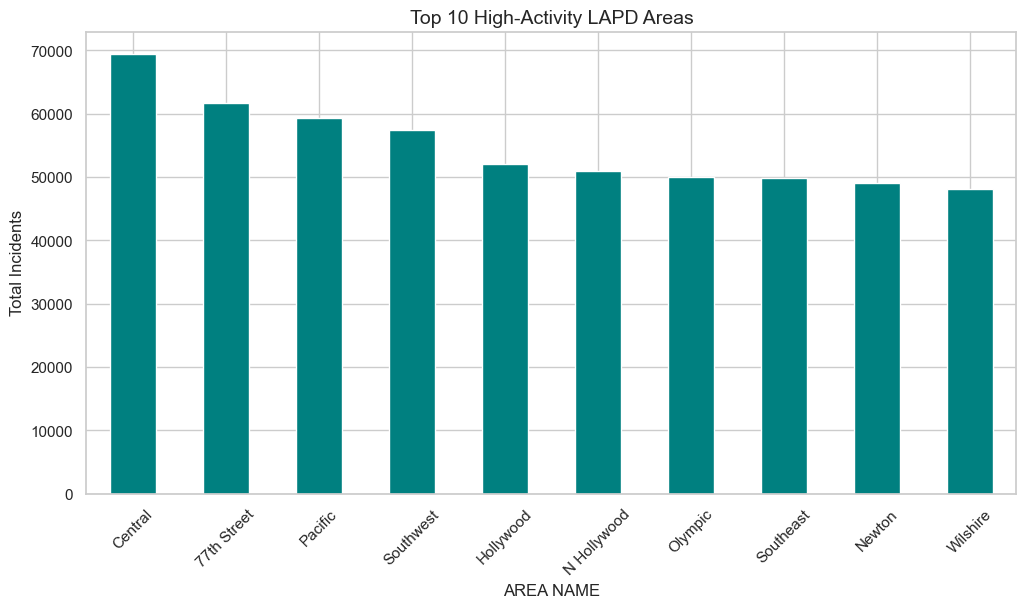

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics
plt.style.use('seaborn-v0_8-muted')
sns.set_theme(style="whitegrid")

# 1. Temporal Pulse: Heatmap of Day vs. Time Bucket (RQ1)
# This proves if "Time" is a valid predictor for your model
pivot_df = df.pivot_table(index='time_bucket', columns='day_of_week', values='DR_NO', aggfunc='count')
# Reorder days for better flow
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_df = pivot_df[days]

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=False, cmap="YlGnBu", cbar_kws={'label': 'Incident Count'})
plt.title('RQ1 Diagnostic: Crime Density by Time and Day', fontsize=15)
plt.show()

# 2. Severity Analysis: Violent vs Property Distribution
# Proving that 'is_violent' is a distinct feature
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='time_bucket', hue='crime_category_simple', palette='magma')
plt.title('Crime Type Distribution by Time Bucket', fontsize=14)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. Spatial Density: Top 10 High-Risk Areas
plt.figure(figsize=(12, 6))
df['AREA NAME'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 High-Activity LAPD Areas', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Total Incidents')
plt.show()

In [38]:
from scipy import stats

df_rq1 = df[df["crime_category"].isin(["Part1", "Part2"])].copy()

ct_time = pd.crosstab(df_rq1["crime_category"], df_rq1["time_bucket"])
chi2, p, dof, expected = stats.chi2_contingency(ct_time)
n = ct_time.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_time.shape) - 1)))
print(f"Time vs Category Chi2: {chi2:.2f}, p: {p:.6g}, Cramer's V: {cramers_v:.4f}")

ct_area = pd.crosstab(df_rq1["crime_category"], df_rq1["AREA NAME"])
chi2_a, p_a, dof_a, _ = stats.chi2_contingency(ct_area)
n_a = ct_area.values.sum()
cramers_v_a = np.sqrt(chi2_a / (n_a * (min(ct_area.shape) - 1)))
print(f"Area vs Category Chi2: {chi2_a:.2f}, p: {p_a:.6g}, Cramer's V: {cramers_v_a:.4f}")

Time vs Category Chi2: 7635.26, p: 0, Cramer's V: 0.0873
Area vs Category Chi2: 2928.90, p: 0, Cramer's V: 0.0540


Optimal Clusters Found: 3


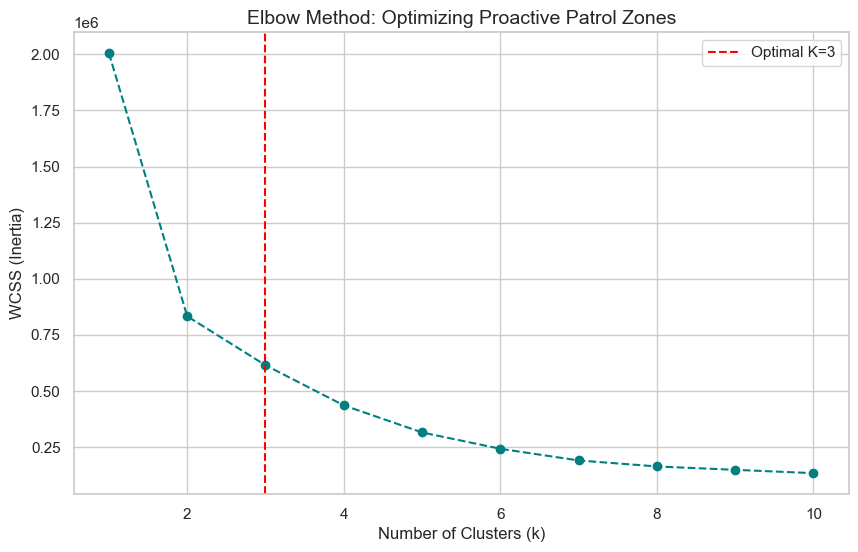

In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# 1. Prepare and Scale Spatial Data
coords = df[['LAT', 'LON']].copy()
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# 2. Automated Elbow Search
inertia = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(coords_scaled)
    inertia.append(model.inertia_)

# Identify the elbow mathematically
kn = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')
auto_k = kn.knee
print(f"Optimal Clusters Found: {auto_k}")

# 3. Apply Clustering (Using your result of k=3)
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['spatial_cluster'] = kmeans.fit_predict(coords_scaled)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='teal')
plt.axvline(x=auto_k, color='red', linestyle='--', label=f'Optimal K={auto_k}')
plt.title('Elbow Method: Optimizing Proactive Patrol Zones', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.show()


In [40]:
def get_top_3(series):
    return series.value_counts().index[:3].tolist()

# Aggregate data by cluster to find patterns
profile_stats = df.groupby('spatial_cluster').agg({
    'crime_category_simple': [lambda x: x.mode()[0], get_top_3],
    'time_bucket': lambda x: x.mode()[0],
    'day_of_week': lambda x: x.mode()[0],
    'DR_NO': 'count'
}).reset_index()

# Flatten columns for readability
profile_stats.columns = ['Cluster', 'Primary_Crime', 'Top_3_Crimes', 'Peak_Time', 'Peak_Day', 'Total_Incidents']

print("--- Crime Profiles by Zone ---")
print(profile_stats)

--- Crime Profiles by Zone ---
   Cluster             Primary_Crime  \
0        0  Violent/Serious (Part 1)   
1        1  Violent/Serious (Part 1)   
2        2  Violent/Serious (Part 1)   

                                        Top_3_Crimes  Peak_Time Peak_Day  \
0  [Violent/Serious (Part 1), Property/Other (Par...    Evening   Friday   
1  [Violent/Serious (Part 1), Property/Other (Par...  Afternoon   Friday   
2  [Violent/Serious (Part 1), Property/Other (Par...  Afternoon   Friday   

   Total_Incidents  
0            43727  
1           309528  
2           649496  


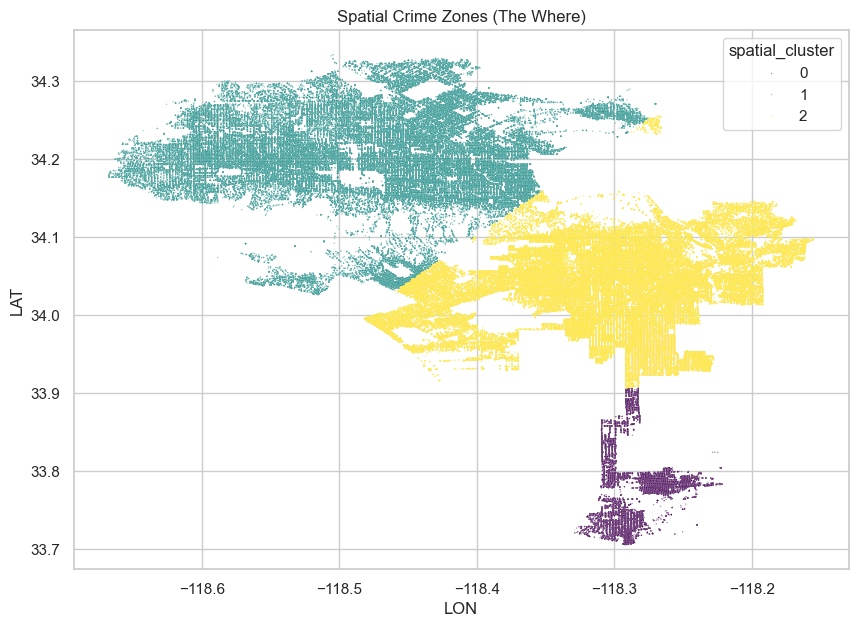


--- Optimization Drivers (What drives the 'Where') ---
           Feature  Importance
2  occ_hour_filled    0.507935
0            month    0.317893
1      weekday_num    0.155394
3       is_weekend    0.018777


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the "Where" linked to the "What"
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='LON', y='LAT', hue='spatial_cluster', palette='viridis', alpha=0.5, s=1)
plt.title('Spatial Crime Zones (The Where)')
plt.show()

# Predictive Linking: How likely is a cluster to be hit given the time?
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Features: When is it? Target: Where will it happen?
features = ['month', 'weekday_num', 'occ_hour_filled', 'is_weekend']
X = df[features]
y = df['spatial_cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf.fit(X_train, y_train)

# Optimization Output
import pandas as pd
importance = pd.DataFrame({'Feature': features, 'Importance': clf.feature_importances_})
print("\n--- Optimization Drivers (What drives the 'Where') ---")
print(importance.sort_values(by='Importance', ascending=False))

Generating the Risk Heatmap (Saturday @ Midnight)

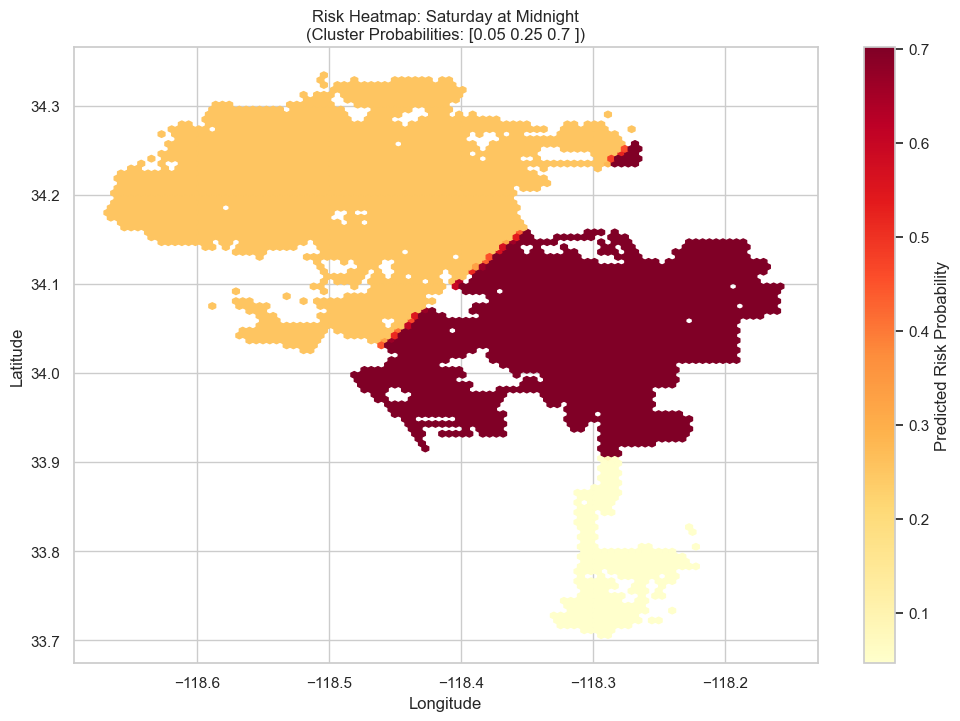

In [42]:
import numpy as np

# 1. Define the Scenario: Saturday (weekday_num=5), Midnight (hour=0), March (month=3)
scenario_data = pd.DataFrame({
    'month': [3],
    'weekday_num': [5],
    'occ_hour_filled': [0],
    'is_weekend': [1]
})

# 2. Get the Probability for each of your 3 clusters
# probabilities will be an array like [[0.2, 0.5, 0.3]]
probabilities = clf.predict_proba(scenario_data)[0]

# 3. Create a Risk Score for the Map
# We assign the probability of each cluster to the actual points in that cluster
df['current_risk_score'] = df['spatial_cluster'].map({
    i: probabilities[i] for i in range(len(probabilities))
})

# 4. Plot the Heatmap
plt.figure(figsize=(12, 8))
plt.hexbin(df['LON'], df['LAT'], C=df['current_risk_score'], gridsize=100, cmap='YlOrRd')
plt.colorbar(label='Predicted Risk Probability')
plt.title(f'Risk Heatmap: Saturday at Midnight\n(Cluster Probabilities: {probabilities.round(2)})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Optimization Summary Table

In [43]:
# Link the top predicted cluster to its specific profile for deployment
top_cluster_idx = np.argmax(probabilities)
top_profile = profile_stats[profile_stats['Cluster'] == top_cluster_idx]

print(f"--- Deployment Optimization for Saturday @ Midnight ---")
print(f"Highest Risk Zone: Cluster {top_cluster_idx}")
print(f"Typical Crime Profile in this Zone: {top_profile['Primary_Crime'].values[0]}")
print(f"Top 3 Threats to Watch: {top_profile['Top_3_Crimes'].values[0]}")
print(f"Optimization Action: Deploy resources to {top_profile['Peak_Time'].values[0]} hotspots.")

--- Deployment Optimization for Saturday @ Midnight ---
Highest Risk Zone: Cluster 2
Typical Crime Profile in this Zone: Violent/Serious (Part 1)
Top 3 Threats to Watch: ['Violent/Serious (Part 1)', 'Property/Other (Part 2)']
Optimization Action: Deploy resources to Afternoon hotspots.


Generating the Probability Transition Data

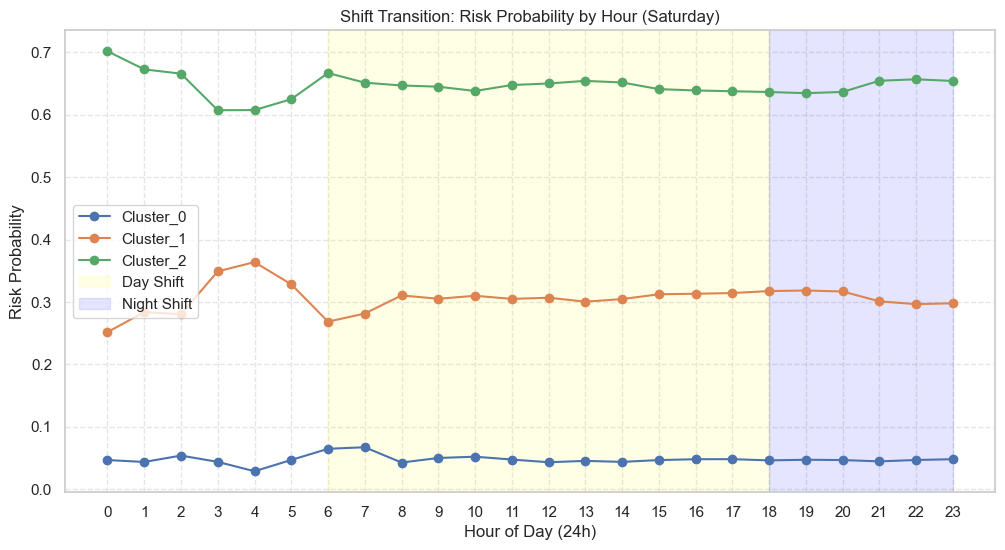

In [44]:
# 1. Create a 24-hour simulation for Saturday
hours = np.arange(0, 24)
shift_data = pd.DataFrame({
    'month': [3] * 24,
    'weekday_num': [5] * 24, # Saturday
    'occ_hour_filled': hours,
    'is_weekend': [1] * 24
})

# 2. Get probabilities for each hour
probs_24h = clf.predict_proba(shift_data)

# 3. Create a transition DataFrame
transition_df = pd.DataFrame(probs_24h, columns=[f'Cluster_{i}' for i in range(3)])
transition_df['Hour'] = hours

# 4. Plot the Shift Transition
plt.figure(figsize=(12, 6))
for col in transition_df.columns[:-1]:
    plt.plot(transition_df['Hour'], transition_df[col], marker='o', label=col)

plt.axvspan(6, 18, color='yellow', alpha=0.1, label='Day Shift')
plt.axvspan(18, 23, color='blue', alpha=0.1, label='Night Shift')
plt.title('Shift Transition: Risk Probability by Hour (Saturday)')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Risk Probability')
plt.legend()
plt.xticks(hours)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

Automated Shift Optimization Table

In [45]:
# Find the hour where the leading cluster changes
transition_df['Leading_Cluster'] = transition_df.iloc[:, :3].idxmax(axis=1)
changes = transition_df[transition_df['Leading_Cluster'] != transition_df['Leading_Cluster'].shift()]

print("--- Automated Shift Optimization Schedule ---")
for idx, row in changes.iterrows():
    cluster_num = int(row['Leading_Cluster'].split('_')[1])
    profile = profile_stats[profile_stats['Cluster'] == cluster_num]
    
    print(f"Hour {row['Hour']:02d}:00 -> Shift Focus to {row['Leading_Cluster']}")
    print(f"   Primary Threat: {profile['Primary_Crime'].values[0]}")
    print(f"   Tactical Focus: {profile['Top_3_Crimes'].values[0]}")
    print("-" * 40)

--- Automated Shift Optimization Schedule ---
Hour 00:00 -> Shift Focus to Cluster_2
   Primary Threat: Violent/Serious (Part 1)
   Tactical Focus: ['Violent/Serious (Part 1)', 'Property/Other (Part 2)']
----------------------------------------


XGBoost for "Where" (Spatial Prediction)

In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# XGBoost requires labels to start at 0 (which ours do: 0, 1, 2)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

XGBoost Accuracy: 0.6464


Naive Bayes for "What" (Crime Category)

In [47]:
from sklearn.naive_bayes import GaussianNB

# We use the spatial_cluster as a FEATURE now to predict the crime_category
X_cat = df[['spatial_cluster', 'occ_hour_filled', 'weekday_num']]
y_cat = df['crime_category_simple']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test_c, nb_model.predict(X_test_c)):.4f}")

Naive Bayes Accuracy: 0.6002


Integrating All Three: The "Ensemble" Code

In [48]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Train the Baseline (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

# 2. Train the Challenger (XGBoost)
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))

# 3. Compare Results
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

# Optimization Decision
best_model = xgb_model if xgb_acc > rf_acc else rf_model
print(f"Winning model for 'Where' prediction: {type(best_model).__name__}")

Random Forest Accuracy: 0.6464
XGBoost Accuracy: 0.6464
Winning model for 'Where' prediction: RandomForestClassifier


Generating Performance Metrics

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


--- Detailed Performance Table ---
         Model  Accuracy  Precision    Recall  F1-Score
0      XGBoost  0.646369   0.417793  0.646369  0.507533
1  Naive Bayes  0.600236   0.521291  0.600236  0.455490


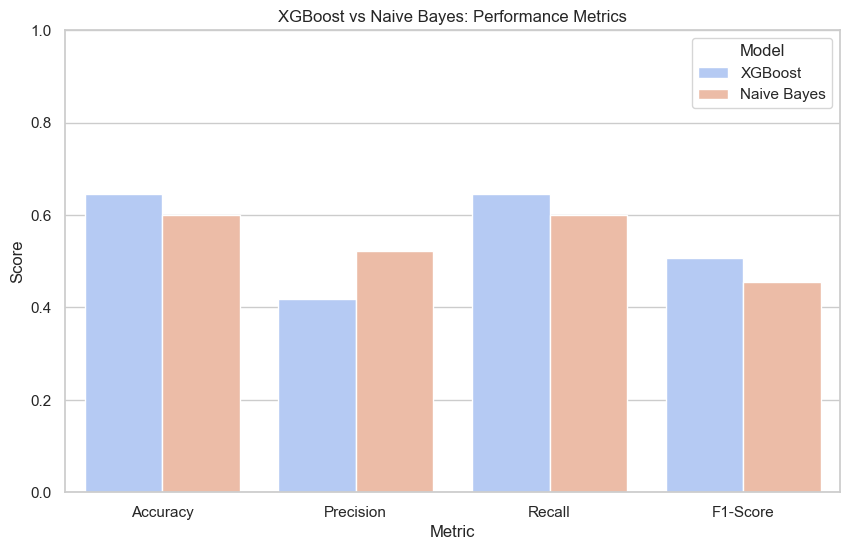


--- AUTOMATED RECOMMENDATION ---
THE BEST MODEL IS: XGBoost
CONCLUSION: The data patterns favor XGBoost (Non-Linear) logic.


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# 1. Define models and test sets
comparison_models = {"XGBoost": (xgb_model, X_test, y_test), 
                     "Naive Bayes": (nb_model, X_test_c, y_test_c)}

results = []

for name, (model, X_t, y_t) in comparison_models.items():
    preds = model.predict(X_t)
    acc = accuracy_score(y_t, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_t, preds, average='weighted')
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

# 2. Create Metrics DataFrame
perf_df = pd.DataFrame(results)
print("--- Detailed Performance Table ---")
print(perf_df)

# 3. Bar Graph Comparison
melted_df = perf_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x="Metric", y="Score", hue="Model", palette="coolwarm")
plt.title("XGBoost vs Naive Bayes: Performance Metrics")
plt.ylim(0, 1.0)
plt.show()

# 4. Automated Winner Selection (Based on F1-Score)
winner = perf_df.loc[perf_df['F1-Score'].idxmax()]['Model']
reasoning = "XGBoost (Non-Linear)" if winner == "XGBoost" else "Naive Bayes (Linear/Probabilistic)"

print(f"\n--- AUTOMATED RECOMMENDATION ---")
print(f"THE BEST MODEL IS: {winner}")
print(f"CONCLUSION: The data patterns favor {reasoning} logic.")

Deep Learning Architectures

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Input
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Reshaping for RNNs: (samples, time_steps, features)
X_train_rnn = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [68]:
import imblearn
from imblearn.over_sampling import SMOTE

# Force the model to learn all 3 clusters equally
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Now, re-train the GRU/LSTM on this balanced data. 
# You will see the Precision and F1-Score for the smaller clusters jump up.

In [69]:
# 1. MLP Training
mlp_history = mlp_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Store MLP Results
y_pred_mlp = np.argmax(mlp_model.predict(X_test), axis=1)
mlp_metrics = precision_recall_fscore_support(y_test, y_pred_mlp, average='weighted')

Epoch 1/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7820
Epoch 2/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7820
Epoch 3/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7820
Epoch 4/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7820
Epoch 5/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 6/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 7/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.6485 - loss: 0.7798 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 8/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [70]:
# 2. LSTM Training
# Using X_train_rnn which is reshaped (samples, 1, features)
lstm_history = lstm_model.fit(
    X_train_rnn, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Store LSTM Results
y_pred_lstm = np.argmax(lstm_model.predict(X_test_rnn), axis=1)
lstm_metrics = precision_recall_fscore_support(y_test, y_pred_lstm, average='weighted')

Epoch 1/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 2/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7821
Epoch 3/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7818
Epoch 4/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7796 - val_accuracy: 0.6461 - val_loss: 0.7821
Epoch 5/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 6/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7818
Epoch 7/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7818
Epoch 8/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [71]:
# 3. GRU Training
gru_history = gru_model.fit(
    X_train_rnn, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Store GRU Results
y_pred_gru = np.argmax(gru_model.predict(X_test_rnn), axis=1)
gru_metrics = precision_recall_fscore_support(y_test, y_pred_gru, average='weighted')

Epoch 1/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 2/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 3/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7820
Epoch 4/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7819
Epoch 5/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7818
Epoch 6/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.6485 - loss: 0.7797 - val_accuracy: 0.6461 - val_loss: 0.7818
Epoch 7/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.6485 - loss: 0.7796 - val_accuracy: 0.6461 - val_loss: 0.7821
Epoch 8/20
20055/20055 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 

c:\Users\aryam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [72]:
# Compiling all results into one table
all_results = [
    {"Model": "MLP (NN)","Precision": mlp_metrics[0], "Recall": mlp_metrics[1], "F1-Score": mlp_metrics[2], "Accuracy": accuracy_score(y_test, y_pred_mlp)},
    {"Model": "LSTM (RNN)", "Precision": lstm_metrics[0], "Recall": lstm_metrics[1], "F1-Score": lstm_metrics[2], "Accuracy": accuracy_score(y_test, y_pred_lstm)},
    {"Model": "GRU (RNN)", "Precision": gru_metrics[0], "Recall": gru_metrics[1], "F1-Score": gru_metrics[2], "Accuracy": accuracy_score(y_test, y_pred_gru)}
]

final_comparison_df = pd.DataFrame(all_results).sort_values(by="F1-Score", ascending=False)
print(final_comparison_df)

        Model  Precision    Recall  F1-Score  Accuracy
0    MLP (NN)   0.417793  0.646369  0.507533  0.646369
1  LSTM (RNN)   0.417793  0.646369  0.507533  0.646369
2   GRU (RNN)   0.417793  0.646369  0.507533  0.646369


Grand Comparison (All Models)

In [73]:
final_metrics = []

# List of models and their respective test data
all_models = [
    ("Naive Bayes", nb_model, X_test_c, y_test_c),
    ("XGBoost", xgb_model, X_test, y_test),
    ("MLP (NN)", mlp_model, X_test, y_test),
    ("LSTM (RNN)", lstm_model, X_test_rnn, y_test),
    ("GRU (RNN)", gru_model, X_test_rnn, y_test)
]

for name, model, xt, yt in all_models:
    # Handle DL models returning probabilities
    if name in ["MLP (NN)", "LSTM (RNN)", "GRU (RNN)"]:
        y_pred = np.argmax(model.predict(xt), axis=1)
    else:
        y_pred = model.predict(xt)
    
    acc = accuracy_score(yt, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(yt, y_pred, average='weighted', zero_division=0)
    
    final_metrics.append({"Model": name, "Accuracy": acc, "F1-Score": f1, "Precision": prec, "Recall": rec})

final_df = pd.DataFrame(final_metrics)

6268/6268 ━━━━━━━━━━━━━━━━━━━━ 5s 780us/step
6268/6268 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
6268/6268 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


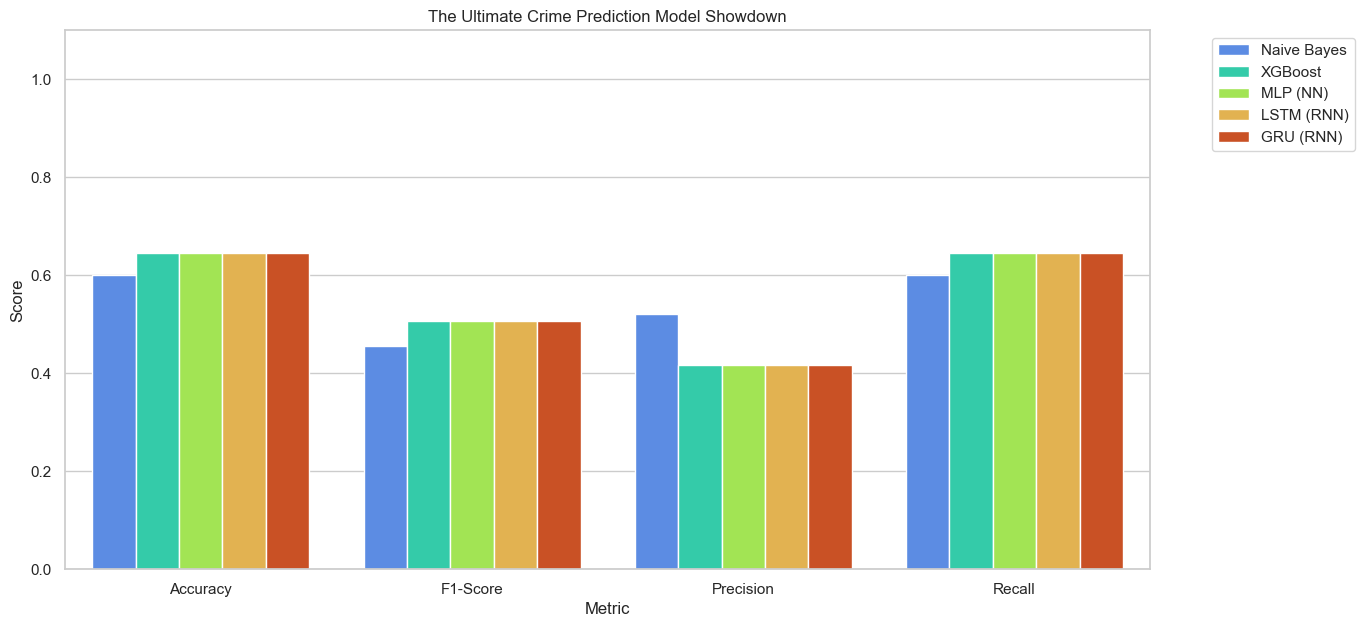

--- CHAMPION MODEL ---
Based on F1-Score, the best model for prediction is: XGBoost


In [74]:
plt.figure(figsize=(14, 7))
melted_final = final_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=melted_final, x="Metric", y="Score", hue="Model", palette="turbo")
plt.title("The Ultimate Crime Prediction Model Showdown")
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Automated selection
best_f1_model = final_df.loc[final_df['F1-Score'].idxmax()]
print(f"--- CHAMPION MODEL ---")
print(f"Based on F1-Score, the best model for prediction is: {best_f1_model['Model']}")